# Análisis Exploratorio y NLP (Rol A)
En este notebook haremos el EDA básico y el análisis de sentimiento de los tweets para cumplir con la rúbrica del proyecto.

In [6]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.5 MB/s  0:00:00


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import os
# Configuracion basica para graficos
plt.style.use('ggplot')

In [8]:
print(os.getcwd())

C:\Users\acost\Documents\proyecto_analisis\Proyecto-Final-Analisis-de-datos\ipynb


## 1. Análisis de Sentimiento (NLP) en Tweets

C:\Users\acost\AppData\Local\Temp\ipykernel_11908\3548867312.py:2: DtypeWarning: Columns (0,2,4,5,6,8,10,12,13,14,16,17,18,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tweets = pd.read_csv('../datasets_consolidados/tweets_consolidados.csv')


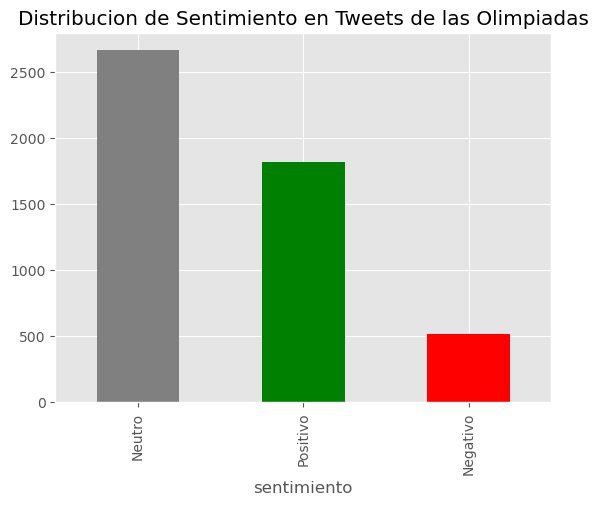

In [10]:
# Cargar datos consolidados de twitter
df_tweets = pd.read_csv('../datasets_consolidados/tweets_consolidados.csv')

# Para que no tarde mucho, sacamos una muestra aleatoria de 5000 tweets
muestra = df_tweets.dropna(subset=['text']).sample(5000, random_state=42).copy()

def obtener_sentimiento(texto):
    # Usamos textblob para sacar la polaridad (-1 negativo, 1 positivo)
    analisis = TextBlob(str(texto))
    return analisis.sentiment.polarity

muestra['polaridad'] = muestra['text'].apply(obtener_sentimiento)

# Clasificar en positivo, neutro, negativo
muestra['sentimiento'] = 'Neutro'
muestra.loc[muestra['polaridad'] > 0.1, 'sentimiento'] = 'Positivo'
muestra.loc[muestra['polaridad'] < -0.1, 'sentimiento'] = 'Negativo'

muestra['sentimiento'].value_counts().plot(kind='bar', color=['gray', 'green', 'red'])
plt.title('Distribucion de Sentimiento en Tweets de las Olimpiadas')
plt.show()

## 2. Modelado y EDA (Correlación Básica)

In [ ]:
# Cargar datos del Banco Mundial
df_pib = pd.read_json('../datasets/api_rest_pib_historico.json')
df_pob = pd.read_json('../datasets/api_rest_poblacion_paises.json')

# Unimos por codigo iso para ver correlacion
df_economia = pd.merge(df_pib, df_pob, on='codigo_iso', suffixes=('_pib', '_pob'))

# Filtramos solo el año 2020 para comparar
df_2020 = df_economia[df_economia['anio'] == '2020'].copy()

# Grafico de dispercion PIB per capita vs Poblacion
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_2020, x='pib_per_capita_usd', y='poblacion')
plt.title('Relacion entre PIB per Capita y Poblacion (2020)')
plt.xlabel('PIB per capita (USD)')
plt.ylabel('Poblacion Total')
plt.show()

print("Correlación de Pearson:")
print(df_2020[['pib_per_capita_usd', 'poblacion']].corr())